# Grad-CAM Visualization

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
import torch.nn as nn

from PIL import Image
from pathlib import Path

from torchvision import transforms
from torchvision.models import efficientnet_b0
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
print("Grad-CAM libraries imported successfully!")

Grad-CAM libraries imported successfully!


In [2]:
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


# Load the Trained Model

In [4]:
# Load EfficientNet-B0
model = efficientnet_b0(weights=None)

# Replace classifier
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    len(class_names)
)

# Load trained weights
model.load_state_dict(
    torch.load(
        "../models/best_efficientnet_b0.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

print("Model loaded successfully!")

Model loaded successfully!


# Load Test MRI Image

Selected Image: ..\data\raw\Testing\glioma\Te-gl_1.jpg


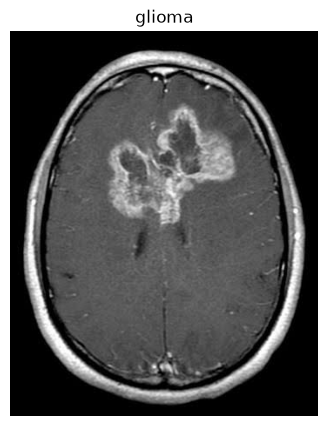

In [5]:
test_dir = Path("../data/raw/Testing")

image_extensions = {".jpg", ".jpeg", ".png"}

image_path = next(
    img for img in test_dir.rglob("*")
    if img.suffix.lower() in image_extensions
)

print("Selected Image:", image_path)

original_image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(original_image)
plt.title(image_path.parent.name)
plt.axis("off")
plt.show()

# Generate Grad-CAM Heatmap

### Create Grad-CAM Object

In [6]:
target_layers = [model.features[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

In [7]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

input_tensor = transform(original_image).unsqueeze(0).to(device)

print(input_tensor.shape)

torch.Size([1, 3, 224, 224])


In [8]:
with torch.no_grad():
    outputs = model(input_tensor)
    probabilities = torch.softmax(outputs, dim=1)

predicted_class = torch.argmax(probabilities, dim=1).item()

print(f"Predicted Class : {class_names[predicted_class]}")
print(f"Confidence      : {probabilities[0][predicted_class] * 100:.2f}%")

Predicted Class : glioma
Confidence      : 63.62%


### Generate Heatmap

In [9]:
targets = [ClassifierOutputTarget(predicted_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

# Overlay the Heatmap

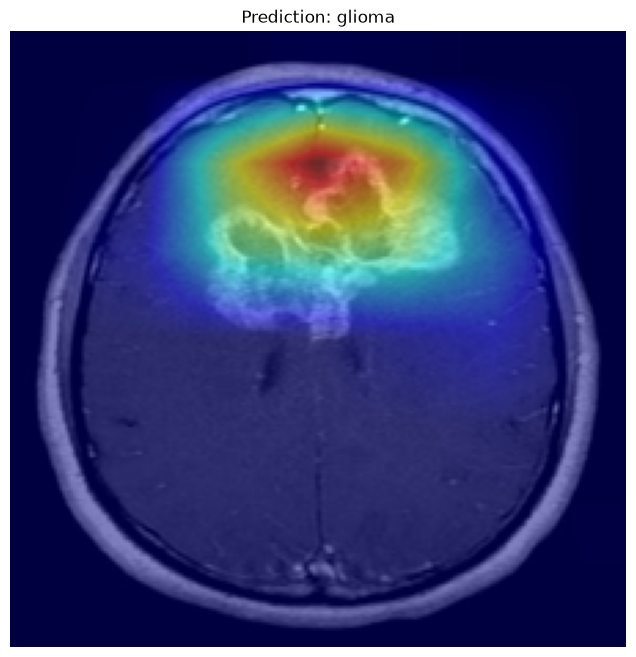

In [10]:
# Converting original image to numpy array
rgb_img = np.array(original_image.resize((224, 224))).astype(np.float32) / 255.0

# Overlay Grad-CAM heatmap
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8, 8))
plt.imshow(visualization)
plt.title(f"Prediction: {class_names[predicted_class]}")
plt.axis("off")
plt.show()

In [11]:
output_dir = Path("../outputs/gradcam")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "gradcam_result.png"

cv2.imwrite(
    str(output_path),
    cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR)
)

print(f"Grad-CAM saved to: {output_path}")

Grad-CAM saved to: ..\outputs\gradcam\gradcam_result.png


# Batch Grad-CAM Visualization

In [12]:
test_dir = Path("../data/raw/Testing")
output_dir = Path("../outputs/gradcam")
output_dir.mkdir(parents=True, exist_ok=True)

image_extensions = {".jpg", ".jpeg", ".png"}

count = 0

for image_path in test_dir.rglob("*"):
    if image_path.suffix.lower() not in image_extensions:
        continue

    original_image = Image.open(image_path).convert("RGB")

    input_tensor = transform(original_image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1)

    predicted_class = probabilities.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(predicted_class)]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    rgb_img = np.array(
        original_image.resize((224,224))
    ).astype(np.float32) / 255.0

    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )

    save_path = output_dir / f"{image_path.stem}_gradcam.png"

    cv2.imwrite(
        str(save_path),
        cv2.cvtColor(visualization, cv2.COLOR_RGB2BGR)
    )

    print(f"Saved: {save_path.name}")

    count += 1

    # Generate only first 10 images
    if count == 10:
        break

print(f"\nGenerated {count} Grad-CAM visualizations.")

Saved: Te-gl_1_gradcam.png
Saved: Te-gl_10_gradcam.png
Saved: Te-gl_100_gradcam.png
Saved: Te-gl_101_gradcam.png
Saved: Te-gl_102_gradcam.png
Saved: Te-gl_103_gradcam.png
Saved: Te-gl_104_gradcam.png
Saved: Te-gl_105_gradcam.png
Saved: Te-gl_106_gradcam.png
Saved: Te-gl_107_gradcam.png

Generated 10 Grad-CAM visualizations.
